In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load the datasets generated by our Bash script
try:
    df_cfs = pd.read_csv('dataset_CFS.csv')
    df_eevdf = pd.read_csv('dataset_EEVDF.csv')
    
    # Combine into a single dataframe for easier seaborn plotting
    df_all = pd.concat([df_cfs, df_eevdf], ignore_index=True)
    print("Datasets loaded successfully! Total samples:", len(df_all))
except FileNotFoundError:
    print("Error: Ensure both CSV files are in the same directory as this notebook.")

Datasets loaded successfully! Total samples: 100


In [2]:
# Calculate descriptive statistics
def calculate_eda(df, scheduler_name):
    mean_lat = df['Max_Latency_us'].mean()
    median_lat = df['Max_Latency_us'].median()
    p99_lat = np.percentile(df['Max_Latency_us'], 99)
    
    print(f"--- {scheduler_name} EDA ---")
    print(f"Mean Max Latency:   {mean_lat:.2f} us")
    print(f"Median Max Latency: {median_lat:.2f} us")
    print(f"p99 Tail Latency:   {p99_lat:.2f} us\n")

calculate_eda(df_all[df_all['Scheduler'] == 'CFS'], "CFS")
calculate_eda(df_all[df_all['Scheduler'] == 'EEVDF'], "EEVDF")

--- CFS EDA ---
Mean Max Latency:   158.66 us
Median Max Latency: 92.50 us
p99 Tail Latency:   500.54 us

--- EEVDF EDA ---
Mean Max Latency:   570.62 us
Median Max Latency: 114.50 us
p99 Tail Latency:   10330.00 us



In [3]:
# Extract the Max Latency arrays
cfs_latency = df_all[df_all['Scheduler'] == 'CFS']['Max_Latency_us']
eevdf_latency = df_all[df_all['Scheduler'] == 'EEVDF']['Max_Latency_us']

# Perform Shapiro-Wilk test for normality (just to prove it's not normal)
stat_cfs, p_cfs = stats.shapiro(cfs_latency)
stat_eevdf, p_eevdf = stats.shapiro(eevdf_latency)
print(f"Shapiro-Wilk p-value (CFS): {p_cfs:.5f} | (EEVDF): {p_eevdf:.5f}")

# Perform Mann-Whitney U Test
u_stat, p_value = stats.mannwhitneyu(eevdf_latency, cfs_latency, alternative='less')

print("\n--- Mann-Whitney U Test Results ---")
print(f"U-Statistic: {u_stat}")
print(f"P-Value:     {p_value:.5e}")

if p_value < 0.05:
    print("Conclusion: EEVDF significantly reduces worst-case latency compared to CFS (p < 0.05).")
else:
    print("Conclusion: No statistically significant latency reduction found for EEVDF.")

Shapiro-Wilk p-value (CFS): 0.00000 | (EEVDF): 0.00000

--- Mann-Whitney U Test Results ---
U-Statistic: 1275.0
P-Value:     5.69793e-01
Conclusion: No statistically significant latency reduction found for EEVDF.


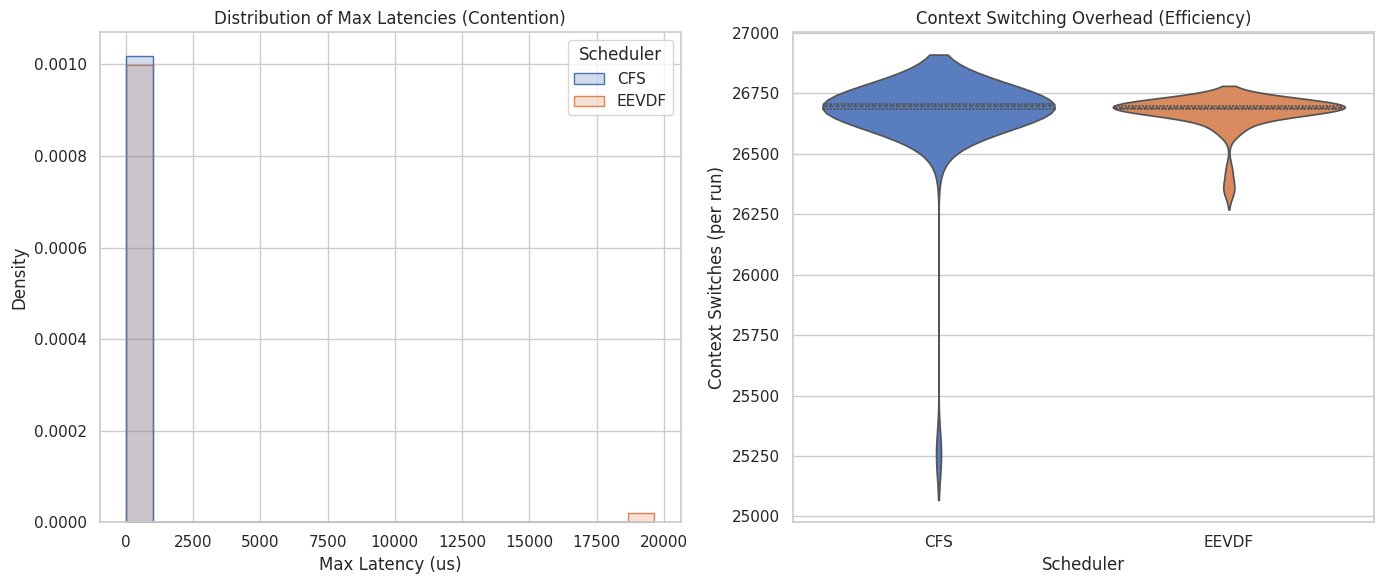

In [4]:
# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Histogram of Latency Distribution
sns.histplot(data=df_all, x="Max_Latency_us", hue="Scheduler", element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Distribution of Max Latencies (Contention)")
axes[0].set_xlabel("Max Latency (us)")

# 2. Violin Plot of Context Switches
# 2. Violin Plot of Context Switches (Updated for modern Seaborn syntax)
sns.violinplot(data=df_all, x="Scheduler", y="Context_Switches", hue="Scheduler", palette="muted", inner="quartile", legend=False, ax=axes[1])
axes[1].set_title("Context Switching Overhead (Efficiency)")
axes[1].set_ylabel("Context Switches (per run)")

plt.tight_layout()
plt.savefig("scheduler_comparison_plots.png", dpi=300)
plt.show()

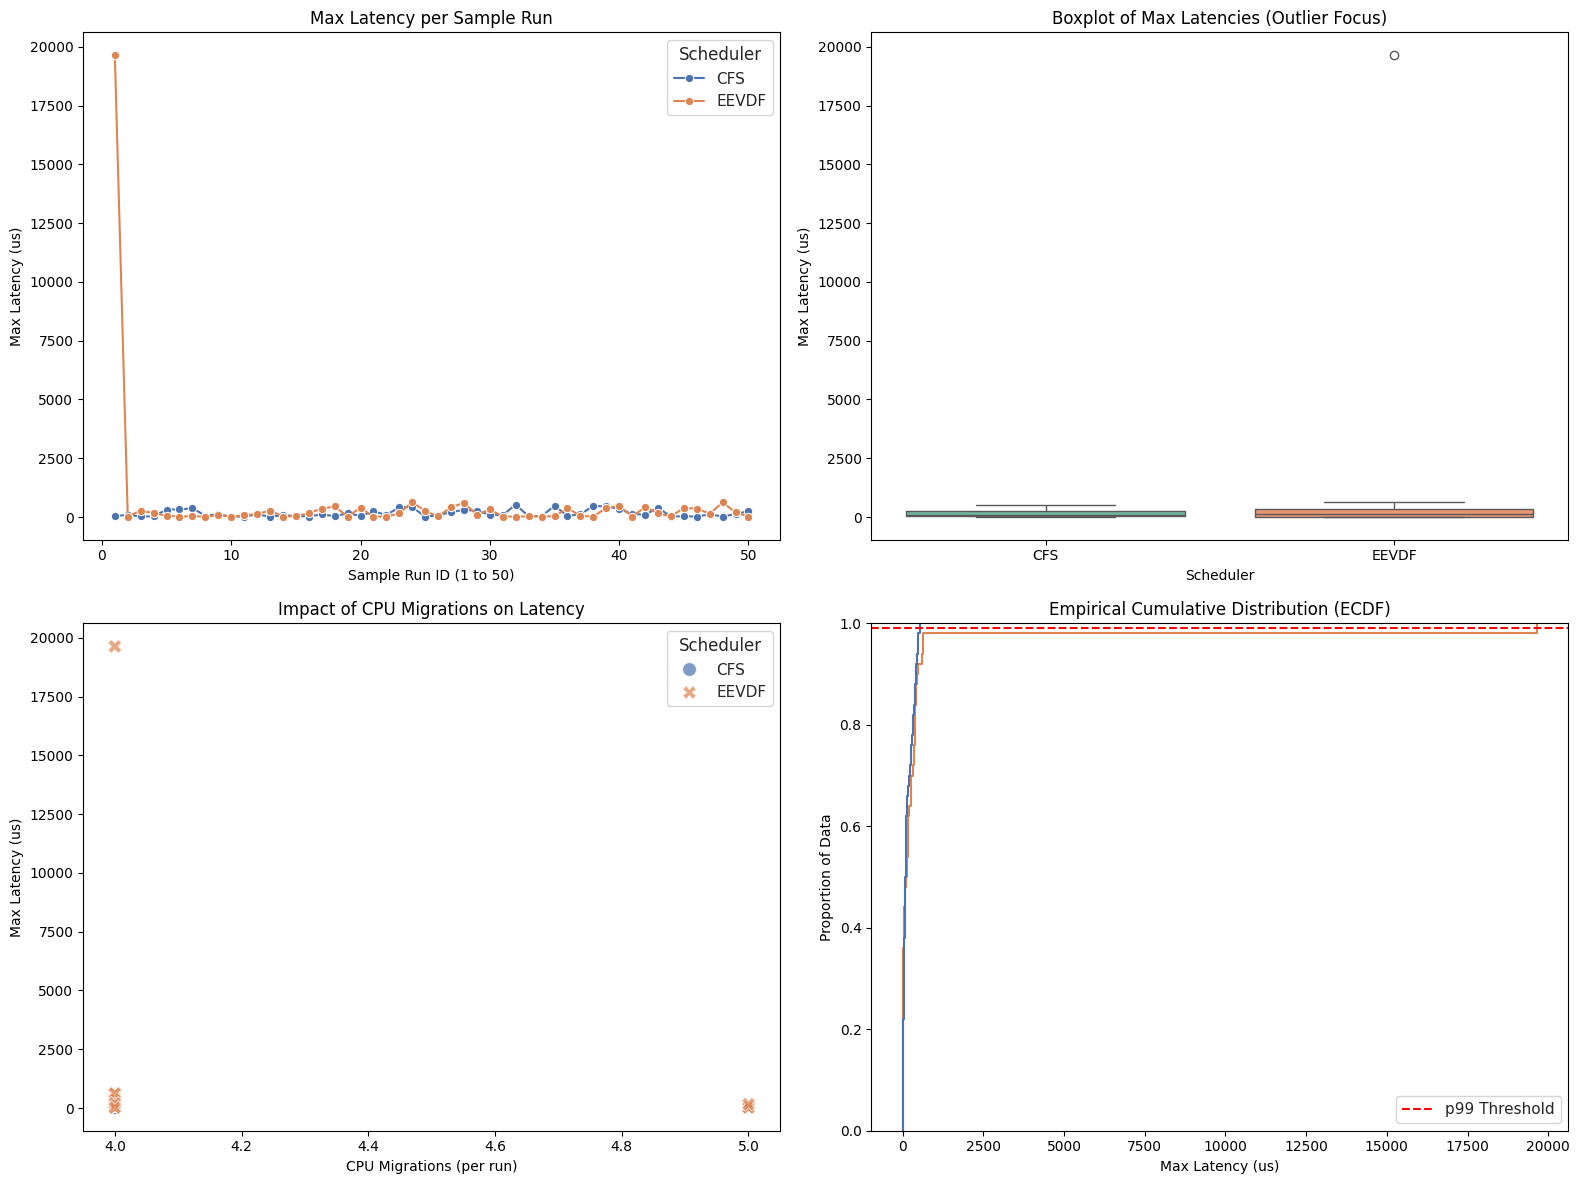

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  # <-- Required to force integer ticks

# Ensure data is loaded
try:
    df_cfs = pd.read_csv('dataset_CFS.csv')
    df_eevdf = pd.read_csv('dataset_EEVDF.csv')
    df_all = pd.concat([df_cfs, df_eevdf], ignore_index=True)
except FileNotFoundError:
    print("Error: Please make sure dataset_CFS.csv and dataset_EEVDF.csv are in the folder.")

# Create a 2x2 grid for advanced visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# 1. Line Plot: Latency Stability over Time (Runs)
sns.lineplot(data=df_all, x="Run_ID", y="Max_Latency_us", hue="Scheduler", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Max Latency per Sample Run")
axes[0, 0].set_ylabel("Max Latency (us)")
axes[0, 0].set_xlabel("Sample Run ID (1 to 50)")

# 2. Boxplot: Highlighting the Outliers (Tail Latency)
sns.boxplot(data=df_all, x="Scheduler", y="Max_Latency_us", hue="Scheduler", palette="Set2", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Boxplot of Max Latencies (Outlier Focus)")
axes[0, 1].set_ylabel("Max Latency (us)")

# 3. UPGRADED: Stripplot (Adds jitter for overlapping dots + Integer Axis)
sns.stripplot(data=df_all, x="CPU_Migrations", y="Max_Latency_us", hue="Scheduler", dodge=True, alpha=0.7, size=7, jitter=True, ax=axes[1, 0])
axes[1, 0].set_title("Impact of CPU Migrations on Latency")
axes[1, 0].set_ylabel("Max Latency (us)")
axes[1, 0].set_xlabel("CPU Migrations (per run)")
axes[1, 0].xaxis.set_major_locator(MaxNLocator(integer=True)) # <-- Forces whole numbers

# 4. ECDF Plot: The Gold Standard for Tail Latency
sns.ecdfplot(data=df_all, x="Max_Latency_us", hue="Scheduler", ax=axes[1, 1])
axes[1, 1].axhline(0.99, color='red', linestyle='--', label='p99 Threshold')
axes[1, 1].set_title("Empirical Cumulative Distribution (ECDF)")
axes[1, 1].set_xlabel("Max Latency (us)")
axes[1, 1].set_ylabel("Proportion of Data")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("advanced_scheduler_analysis.png", dpi=300)
plt.show()